## Nutrition Paradox — SQL Query Results

In [1]:
#Setup
import sqlite3
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

DB_PATH = "../nutrition.db"

def q(sql):
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(sql, conn)
    conn.close()
    return df

# Obesity SQL Queries

# 1. Top 5 regions — highest avg obesity (2022)

In [2]:
# 1 Top 5 regions — highest avg obesity (2022)
sql1 = """
SELECT Region,
       ROUND(AVG(Mean_Estimate),2) AS avg_obesity
FROM obesity
WHERE Year=2022 AND Gender='Both'
GROUP BY Region
ORDER BY avg_obesity DESC
LIMIT 5;
"""
df = q(sql1)
df

,Region,avg_obesity
0,Western Pacific,22.69
1,Americas,21.25
2,Eastern Mediterranean,18.08
3,Europe,13.02
4,None,11.49


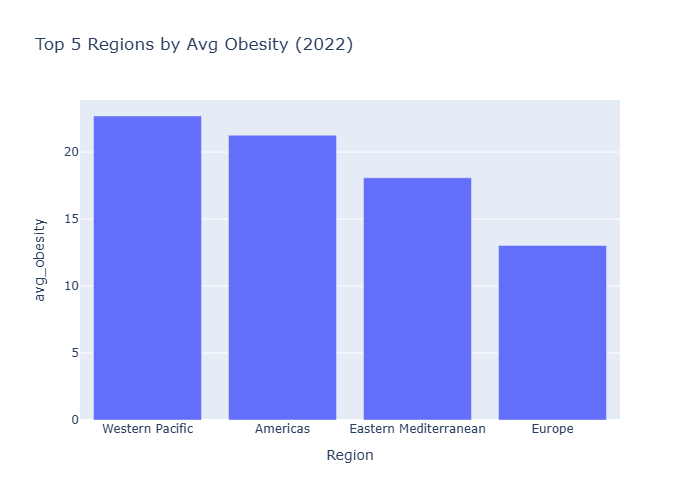

In [3]:
fig = px.bar(
    df,
    x="Region",
    y="avg_obesity",
    title="Top 5 Regions by Avg Obesity (2022)"
)

fig.show("png")

# 2· Top 5 countries — highest obesity estimate

In [4]:
# 2 Top 5 countries — highest obesity estimate

sql = """
SELECT Country,
       ROUND(AVG(Mean_Estimate),2) AS avg_obesity
FROM obesity
WHERE Gender='Both'
GROUP BY Country
ORDER BY avg_obesity DESC
LIMIT 5;
"""
df = q(sql)
display(df)

,Country,avg_obesity
0,Niue,40.52
1,Cook Islands,39.98
2,Nauru,38.62
3,Tokelau,38.03
4,American Samoa,36.97


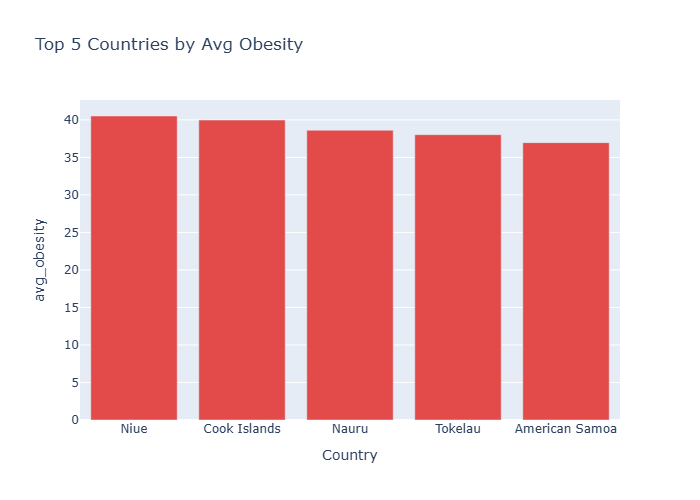

In [5]:
fig = px.bar(
    df,
    x="Country",
    y="avg_obesity",
    title="Top 5 Countries by Avg Obesity",
    color_discrete_sequence=["#E24B4A"]
)
fig.show("png")

# 3. Obesity trend in India


In [6]:
# 3· Obesity trend in India
sql = """
SELECT Year,
       ROUND(AVG(Mean_Estimate),2) AS avg_obesity
FROM obesity
WHERE Country='India' AND Gender='Both'
GROUP BY Year
ORDER BY Year;
"""
df = q(sql)
display(df)

,Year,avg_obesity
0,2012,2.48
1,2013,2.64
2,2014,2.80
3,2015,2.98
4,2016,3.16
5,2017,3.36
6,2018,3.58
7,2019,3.81
8,2020,4.05
9,2021,4.31


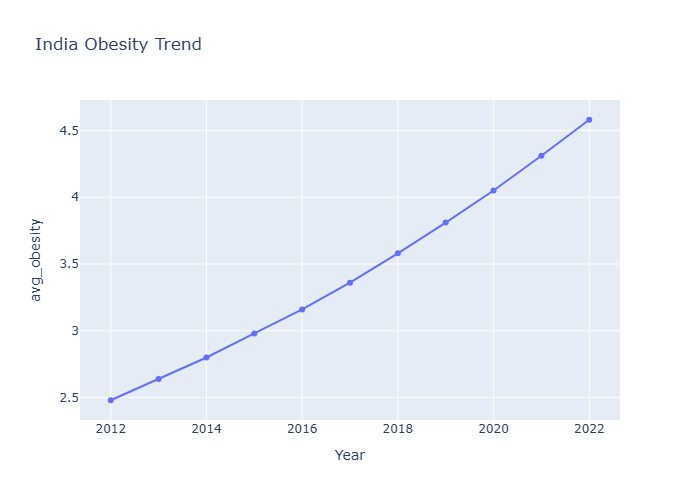

In [7]:
fig = px.line(
    df,
    x="Year",
    y="avg_obesity",
    title="India Obesity Trend",
    markers=True
)
fig.show("png")


# 4· Average obesity by gender

In [8]:
# 4· Average obesity by gender
sql = """
SELECT Gender,
       ROUND(AVG(Mean_Estimate),2) AS avg_obesity
FROM obesity
GROUP BY Gender;
"""
df = q(sql)
display(df)

,Gender,avg_obesity
0,Both,12.78
1,Female,12.72
2,Male,12.78


In [9]:
fig = px.bar(
    df,
    x="Gender",
    y="avg_obesity",
    title="Average Obesity by Gender",
    color="Gender"
)
fig.show()

# 5· Country count by obesity level & age group

In [10]:
# 5· Country count by obesity level & age group
sql = """
SELECT Obesity_Level,
       Age_Group,
       COUNT(DISTINCT Country) AS country_count
FROM obesity
GROUP BY Obesity_Level, Age_Group
ORDER BY Obesity_Level;
"""
df = q(sql)
display(df)


,Obesity_Level,Age_Group,country_count
0,High,Adult,94
1,High,Child/Adolescent,11
2,Low,Adult,176
3,Low,Child/Adolescent,210
4,Moderate,Adult,99
5,Moderate,Child/Adolescent,26


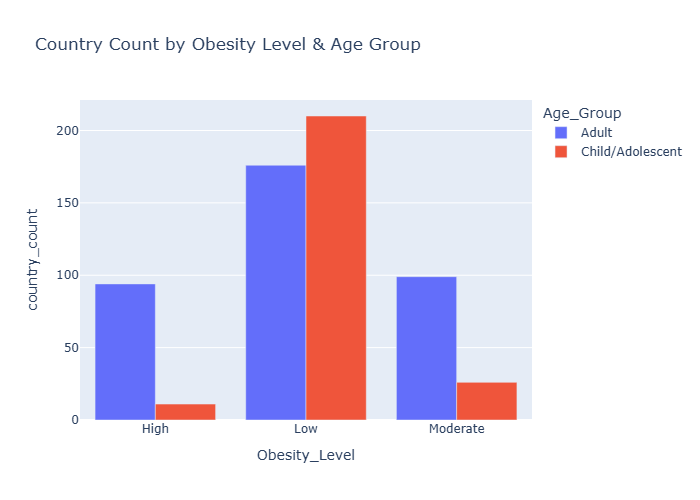

In [11]:
fig = px.bar(
    df,
    x="Obesity_Level",
    y="country_count",
    color="Age_Group",
    barmode="group",
    title="Country Count by Obesity Level & Age Group"
)
fig.show("png")

# Q6 · Least reliable (high CI) & most consistent (low CI) — Top 5 each

In [12]:
# Q6 · Least reliable (high CI) & most consistent (low CI) — Top 5 each

sql = """
SELECT *
FROM (
    SELECT 'Least Reliable' AS type,
           Country,
           ROUND(AVG(CI_Width),2) AS avg_ci
    FROM obesity
    GROUP BY Country
    ORDER BY avg_ci DESC
    LIMIT 5
)

UNION ALL

SELECT *
FROM (
    SELECT 'Most Consistent' AS type,
           Country,
           ROUND(AVG(CI_Width),2) AS avg_ci
    FROM obesity
    GROUP BY Country
    ORDER BY avg_ci ASC
    LIMIT 5
);
"""
df = q(sql)
display(df)

,type,Country,avg_ci
0,Least Reliable,Bermuda,24.59
1,Least Reliable,American Samoa,23.11
2,Least Reliable,Antigua and Barbuda,22.02
3,Least Reliable,Puerto Rico,21.70
4,Least Reliable,Grenada,21.46
5,Most Consistent,Global,0.71
6,Most Consistent,Low & Middle Income,0.86
7,Most Consistent,South-East Asia Region,1.02
8,Most Consistent,India,1.14
9,Most Consistent,Japan,1.16


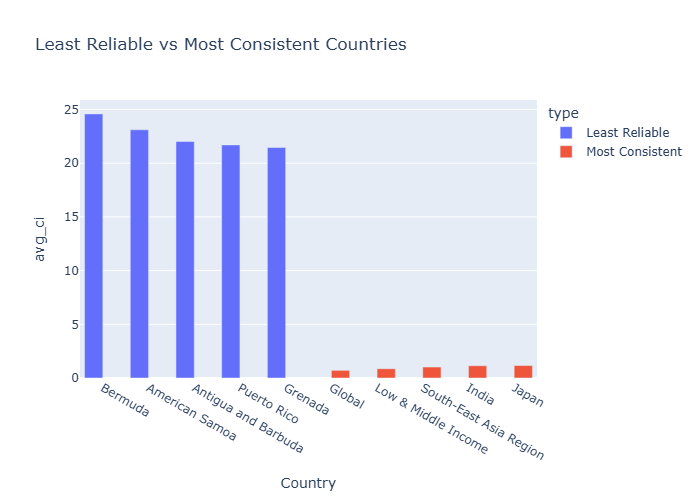

In [13]:
fig = px.bar(
    df,
    x="Country",
    y="avg_ci",
    color="type",
    barmode="group",
    title="Least Reliable vs Most Consistent Countries"
)

fig.show("png")


# 7· Average obesity by age group

In [14]:
# 7· Average obesity by age group

sql = """
SELECT Age_Group,
       ROUND(AVG(Mean_Estimate),2) AS avg_obesity
FROM obesity
WHERE Gender='Both'
GROUP BY Age_Group;
"""
df = q(sql)
display(df)

,Age_Group,avg_obesity
0,Adult,21.85
1,Child/Adolescent,9.76


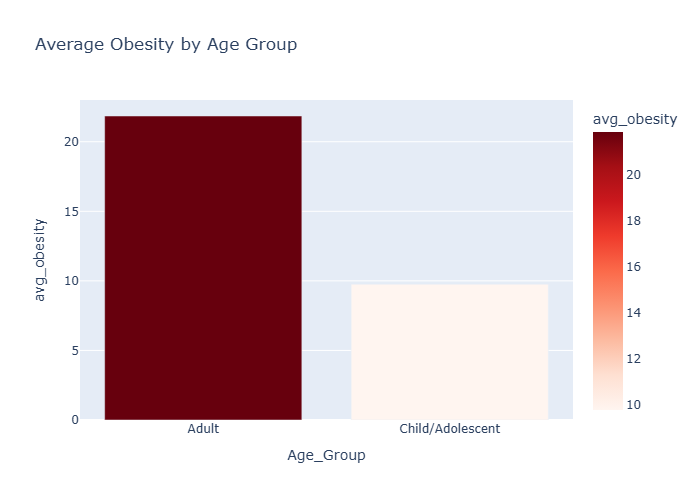

In [15]:
fig = px.bar(
    df,
    x="Age_Group",
    y="avg_obesity",
    title="Average Obesity by Age Group",
    color="avg_obesity",
    color_continuous_scale="Reds"
)

fig.show("png")

# 8· Average obesity by region

In [16]:
# 8· Top 10 consistent low-obesity countries (low mean + low CI)

sql = """
SELECT Country,
       ROUND(AVG(Mean_Estimate),2) AS avg_obesity,
       ROUND(AVG(CI_Width),2) AS avg_ci
FROM obesity
WHERE Gender='Both'
GROUP BY Country
HAVING avg_obesity < 15 AND avg_ci < 5
ORDER BY avg_obesity ASC, avg_ci ASC
LIMIT 10;
"""
df = q(sql)
display(df)

,Country,avg_obesity,avg_ci
0,Timor-Leste,0.99,1.02
1,Ethiopia,1.49,1.27
2,Burkina Faso,1.73,1.24
3,Rwanda,1.79,1.91
4,Bangladesh,1.98,1.30
5,Madagascar,1.99,3.97
6,Burundi,2.30,4.61
7,Malawi,2.42,2.17
8,Nepal,2.51,2.47
9,Eritrea,2.78,4.67


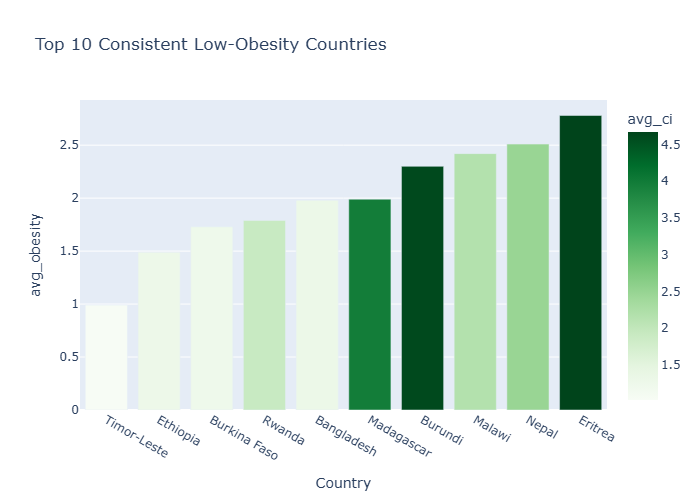

In [17]:
fig = px.bar(
    df,
    x="Country",
    y="avg_obesity",
    title="Top 10 Consistent Low-Obesity Countries",
    color="avg_ci",
    color_continuous_scale="Greens"
)

fig.show("png")

# 9· Countries where female obesity exceeds male by 5+ points

In [18]:
# 9· Countries where female obesity exceeds male by 5+ points

sql = """
SELECT a.Country,
       a.Year,
       ROUND(a.Mean_Estimate,2) AS female_obesity,
       ROUND(b.Mean_Estimate,2) AS male_obesity,
       ROUND(a.Mean_Estimate - b.Mean_Estimate,2) AS gap
FROM obesity a
JOIN obesity b
  ON a.Country=b.Country
  AND a.Year=b.Year
  AND a.Age_Group=b.Age_Group
WHERE a.Gender='Female'
AND b.Gender='Male'
AND (a.Mean_Estimate - b.Mean_Estimate) >= 5
ORDER BY gap DESC
LIMIT 20;
"""
df = q(sql)
display(df)

,Country,Year,female_obesity,male_obesity,gap
0,South Africa,2022,45.73,12.75,32.98
1,South Africa,2021,45.01,12.70,32.32
2,South Africa,2020,44.27,12.63,31.64
3,South Africa,2019,43.51,12.57,30.94
4,South Africa,2018,42.74,12.52,30.23
5,Saint Vincent and the Grenadines,2022,48.77,18.92,29.85
6,Jamaica,2022,48.83,19.04,29.79
7,South Africa,2017,41.97,12.48,29.50
8,Saint Vincent and the Grenadines,2021,47.85,18.37,29.48
9,Jamaica,2021,47.74,18.33,29.41


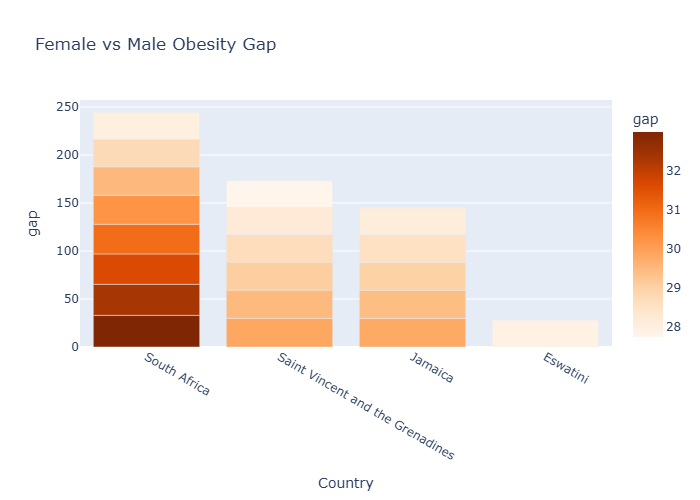

In [19]:
fig = px.bar(
    df,
    x="Country",
    y="gap",
    title="Female vs Male Obesity Gap",
    color="gap",
    color_continuous_scale="Oranges"
)

fig.show("png")

# 10· Global average obesity per year

In [20]:
# 10· Global average obesity per year

sql = """
SELECT Year,
       ROUND(AVG(Mean_Estimate),2) AS global_avg_obesity
FROM obesity
WHERE Gender='Both'
GROUP BY Year
ORDER BY Year;
"""

df = q(sql)
display(df)

,Year,global_avg_obesity
0,2012,11.08
1,2013,11.38
2,2014,11.69
3,2015,12.02
4,2016,12.35
5,2017,12.71
6,2018,13.08
7,2019,13.47
8,2020,13.86
9,2021,14.27


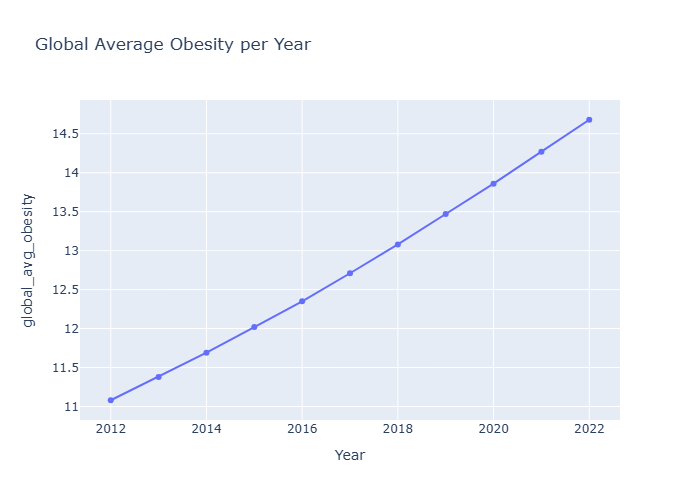

In [21]:
fig = px.line(
    df,
    x="Year",
    y="global_avg_obesity",
    title="Global Average Obesity per Year",
    markers=True
)

fig.show("png")

# Malnutrition SQL Queries

# 1· Avg malnutrition by age group

In [22]:
# 1· Avg malnutrition by age group

sql = """
SELECT Age_Group,
       ROUND(AVG(Mean_Estimate),2) AS avg_malnutrition
FROM malnutrition
WHERE Gender='Both'
GROUP BY Age_Group;
"""
df = q(sql)
display(df)

,Age_Group,avg_malnutrition
0,Adult,5.94
1,Child/Adolescent,5.17


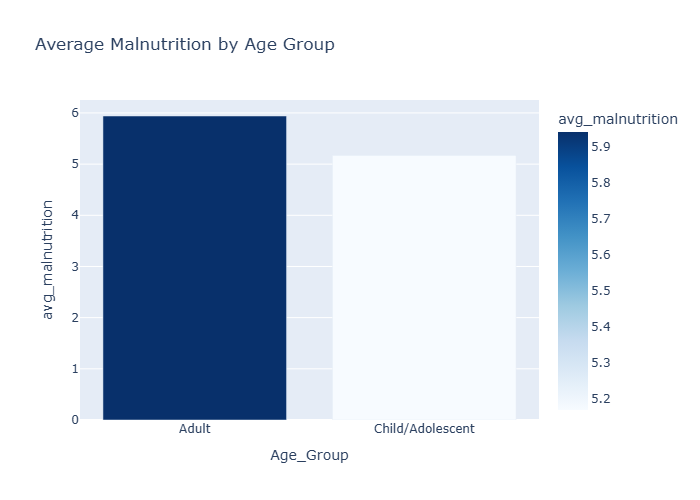

In [23]:
fig = px.bar(
    df,
    x="Age_Group",
    y="avg_malnutrition",
    title="Average Malnutrition by Age Group",
    color="avg_malnutrition",
    color_continuous_scale="Blues"
)
fig.show("png")

# 2· Top 5 countries, highest malnutrition

In [24]:
# 2· Top 5 countries, highest malnutrition

sql = """
SELECT Country,
       ROUND(AVG(Mean_Estimate),2) AS avg_mal
FROM malnutrition
WHERE Gender='Both'
GROUP BY Country
ORDER BY avg_mal DESC
LIMIT 5;
"""
df = q(sql)
display(df)

,Country,avg_mal
0,India,22.19
1,South-East Asia Region,19.28
2,Bangladesh,18.27
3,Sri Lanka,17.86
4,Eritrea,17.48


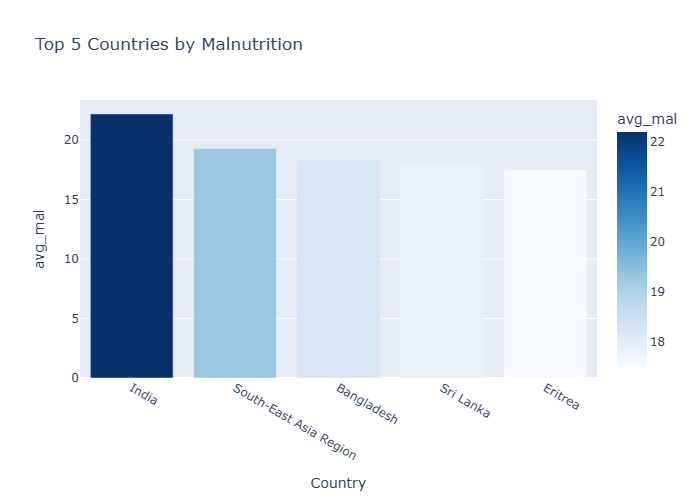

In [25]:
fig = px.bar(
    df,
    x="Country",
    y="avg_mal",
    title="Top 5 Countries by Malnutrition",
    color="avg_mal",
    color_continuous_scale="Blues"
)
fig.show("png")

# 3· Malnutrition trend in Africa over years


In [26]:
# 3· Malnutrition trend in Africa over years
sql = """
SELECT Year,
       ROUND(AVG(Mean_Estimate),2) AS avg_mal
FROM malnutrition
WHERE Region='Africa' AND Gender='Both'
GROUP BY Year
ORDER BY Year;
"""
df = q(sql)
display(df)

,Year,avg_mal
0,2012,8.85
1,2013,8.75
2,2014,8.67
3,2015,8.59
4,2016,8.53
5,2017,8.47
6,2018,8.42
7,2019,8.38
8,2020,8.34
9,2021,8.30


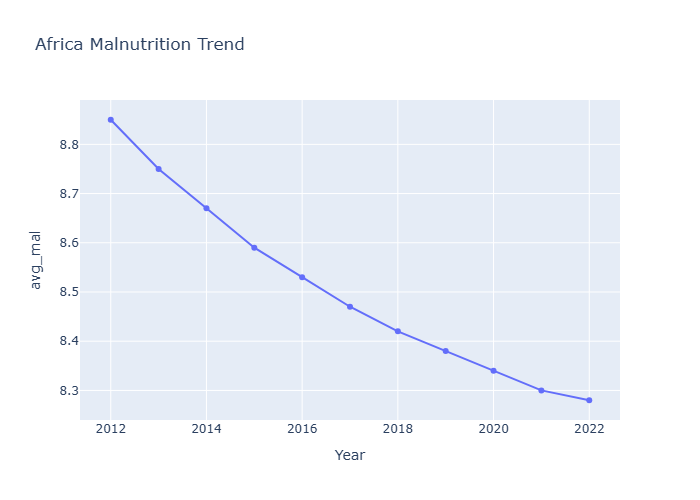

In [27]:
fig = px.line(
    df,
    x="Year",
    y="avg_mal",
    title="Africa Malnutrition Trend",
    markers=True
)
fig.show("png")

# 4· Gender-based average malnutrition

In [28]:
# 4· Gender-based average malnutrition

sql = """
SELECT Gender,
       ROUND(AVG(Mean_Estimate),2) AS avg_mal
FROM malnutrition
GROUP BY Gender
ORDER BY avg_mal DESC;
"""
df = q(sql)
display(df)

,Gender,avg_mal
0,Male,6.03
1,Both,5.36
2,Female,4.68


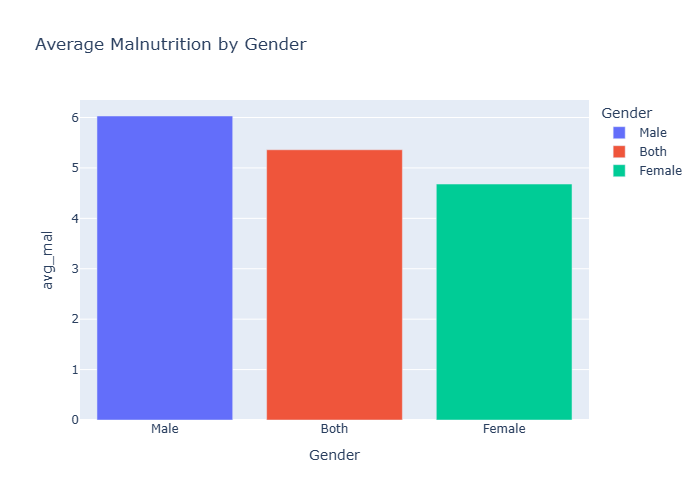

In [29]:
fig = px.bar(
    df,
    x="Gender",
    y="avg_mal",
    title="Average Malnutrition by Gender",
    color="Gender"
)
fig.show("png")

# 5· Avg CI_Width by malnutrition level and age group

In [30]:
# 5· Avg CI_Width by malnutrition level and age group

sql = """
SELECT Malnutrition_Level,
       Age_Group,
       ROUND(AVG(CI_Width),2) AS avg_ci_width
FROM malnutrition
GROUP BY Malnutrition_Level, Age_Group;
"""
df = q(sql)
display(df)

,Malnutrition_Level,Age_Group,avg_ci_width
0,High,Adult,9.25
1,High,Child/Adolescent,7.88
2,Low,Adult,2.64
3,Low,Child/Adolescent,4.44
4,Moderate,Adult,7.64
5,Moderate,Child/Adolescent,9.89


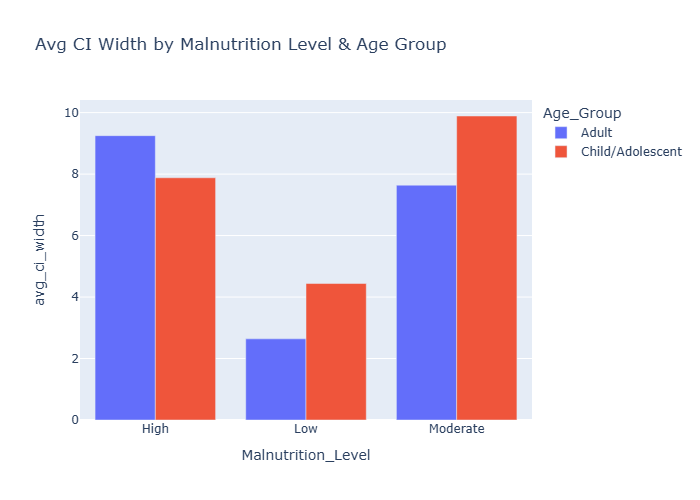

In [31]:
fig = px.bar(
    df,
    x="Malnutrition_Level",
    y="avg_ci_width",
    color="Age_Group",
    barmode="group",
    title="Avg CI Width by Malnutrition Level & Age Group"
)
fig.show("png")

# 6· Yearly malnutrition change — India, Nigeria, Brazil

In [32]:
#6· Yearly malnutrition change — India, Nigeria, Brazil

sql = """
SELECT Country,
       Year,
       ROUND(AVG(Mean_Estimate),2) AS avg_mal
FROM malnutrition
WHERE Country IN ('India','Nigeria','Brazil')
AND Gender='Both'
GROUP BY Country, Year
ORDER BY Country, Year;
"""
df = q(sql)
display(df)

,Country,Year,avg_mal
0,Brazil,2012,2.84
1,Brazil,2013,2.79
2,Brazil,2014,2.74
3,Brazil,2015,2.70
4,Brazil,2016,2.68
5,Brazil,2017,2.66
6,Brazil,2018,2.64
7,Brazil,2019,2.64
8,Brazil,2020,2.63
9,Brazil,2021,2.63


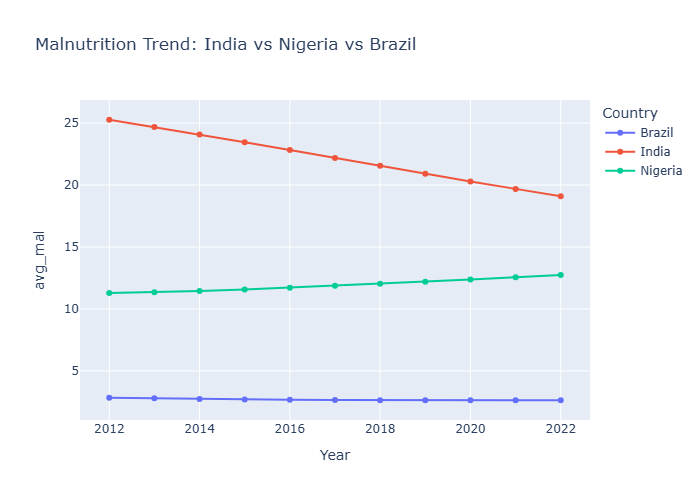

In [33]:
fig = px.line(
    df,
    x="Year",
    y="avg_mal",
    color="Country",
    title="Malnutrition Trend: India vs Nigeria vs Brazil",
    markers=True
)
fig.show("png")

# 7· Regions with lowest malnutrition averages

In [34]:
# 7· Regions with lowest malnutrition averages

sql = """
SELECT Region,
       ROUND(AVG(Mean_Estimate),2) AS avg_mal
FROM malnutrition
WHERE Gender='Both'
GROUP BY Region
ORDER BY avg_mal ASC;
"""
df = q(sql)
display(df)


,Region,avg_mal
0,Europe,2.43
1,Americas,3.18
2,Western Pacific,3.44
3,Eastern Mediterranean,6.67
4,None,8.37
5,Africa,8.51
6,South-East Asia,13.65


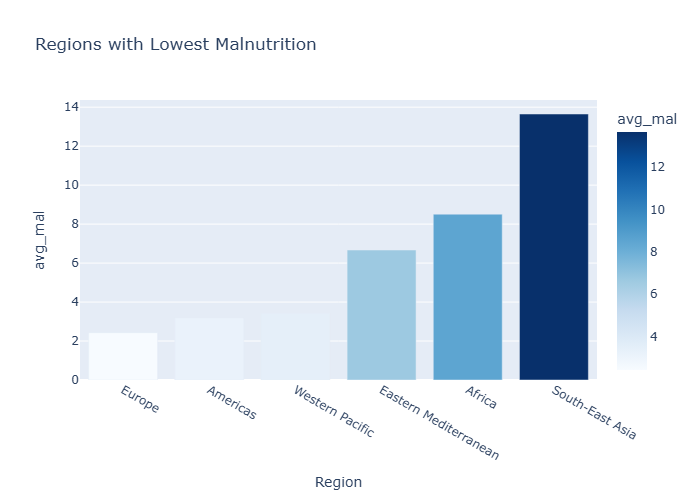

In [35]:
fig = px.bar(
    df,
    x="Region",
    y="avg_mal",
    title="Regions with Lowest Malnutrition",
    color="avg_mal",
    color_continuous_scale="Blues"
)
fig.show("png")

# 8· Countries with increasing malnutrition (recent > early)

In [36]:
# 8· Countries with increasing malnutrition (recent > early)

sql = """
SELECT Country,
       ROUND(MIN(Mean_Estimate),2) AS early_mal,
       ROUND(MAX(Mean_Estimate),2) AS recent_mal,
       ROUND(MAX(Mean_Estimate)-MIN(Mean_Estimate),2) AS increase
FROM malnutrition
WHERE Gender='Both'
GROUP BY Country
HAVING increase > 0
ORDER BY increase DESC
LIMIT 15;
"""
df = q(sql)
display(df)

,Country,early_mal,recent_mal,increase
0,Eritrea,8.94,34.04,25.10
1,Ethiopia,8.51,25.64,17.13
2,Central African Republic,6.35,21.54,15.19
3,Somalia,5.25,19.07,13.82
4,Madagascar,5.44,18.85,13.42
5,India,13.86,26.85,12.99
6,Pakistan,8.40,21.36,12.96
7,South Sudan,5.04,17.22,12.17
8,"Congo, The Democratic Republic of the",5.34,17.24,11.90
9,Viet Nam,8.08,19.82,11.74


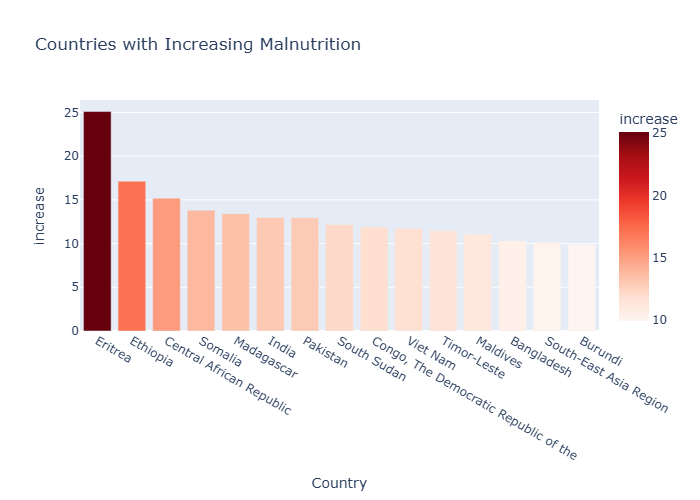

In [37]:
fig = px.bar(
    df,
    x="Country",
    y="increase",
    title="Countries with Increasing Malnutrition",
    color="increase",
    color_continuous_scale="Reds"
)
fig.show("png")

# 9· Min/Max malnutrition levels year-wise

In [38]:
# 9· Min/Max malnutrition levels year-wise

sql = """
SELECT Year,
       ROUND(MIN(Mean_Estimate),2) AS min_mal,
       ROUND(MAX(Mean_Estimate),2) AS max_mal,
       ROUND(AVG(Mean_Estimate),2) AS avg_mal
FROM malnutrition
WHERE Gender='Both'
GROUP BY Year
ORDER BY Year;
"""
df = q(sql)
display(df)

,Year,min_mal,max_mal,avg_mal
0,2012,0.26,34.04,5.57
1,2013,0.26,33.90,5.52
2,2014,0.26,33.78,5.46
3,2015,0.26,33.68,5.42
4,2016,0.27,33.60,5.38
5,2017,0.27,33.55,5.34
6,2018,0.27,33.51,5.31
7,2019,0.26,33.49,5.28
8,2020,0.26,33.47,5.25
9,2021,0.26,33.45,5.23


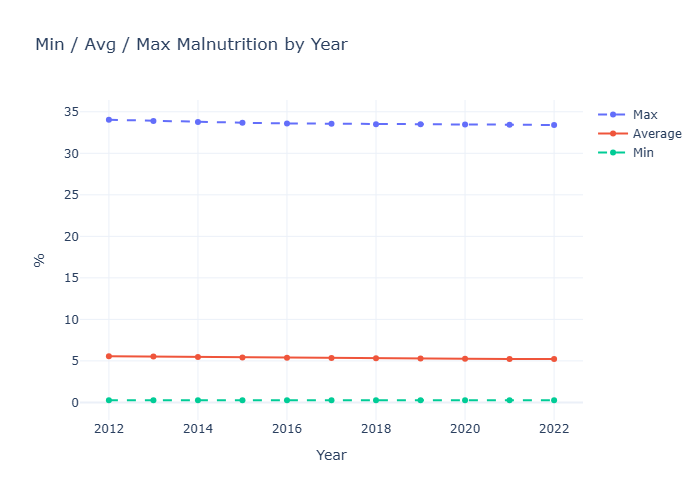

In [39]:
fig = go.Figure()

fig.add_scatter(
    x=df["Year"],
    y=df["max_mal"],
    name="Max",
    line=dict(dash="dash")
)

fig.add_scatter(
    x=df["Year"],
    y=df["avg_mal"],
    name="Average"
)

fig.add_scatter(
    x=df["Year"],
    y=df["min_mal"],
    name="Min",
    line=dict(dash="dash")
)

fig.update_layout(
    title="Min / Avg / Max Malnutrition by Year",
    template="plotly_white",
    xaxis_title="Year",
    yaxis_title="%"
)

fig.show("png")

# 10· High CI_Width flags (CI_Width > 5) for monitoring

In [40]:
# 10· High CI_Width flags (CI_Width > 5) for monitoring

sql = """
SELECT Country,
       Region,
       Year,
       Age_Group,
       Gender,
       ROUND(CI_Width,2) AS ci_width,
       ROUND(Mean_Estimate,2) AS mean_est
FROM malnutrition
WHERE CI_Width > 5
ORDER BY CI_Width DESC
LIMIT 30;
"""
df = q(sql)
display(df)

,Country,Region,Year,Age_Group,Gender,ci_width,mean_est
0,Senegal,Africa,2022,Child/Adolescent,Male,26.70,16.94
1,Senegal,Africa,2021,Child/Adolescent,Male,25.68,16.99
2,Senegal,Africa,2020,Child/Adolescent,Male,24.59,17.05
3,Mauritania,Africa,2022,Child/Adolescent,Male,23.81,16.08
4,Senegal,Africa,2019,Child/Adolescent,Male,23.47,17.11
5,Equatorial Guinea,Africa,2022,Adult,Male,23.42,14.01
6,Senegal,Africa,2022,Child/Adolescent,Male,23.39,24.02
7,Senegal,Africa,2022,Child/Adolescent,Male,23.37,21.38
8,Somalia,Eastern Mediterranean,2022,Adult,Male,23.08,25.52
9,Gambia,Africa,2022,Child/Adolescent,Male,23.01,12.85


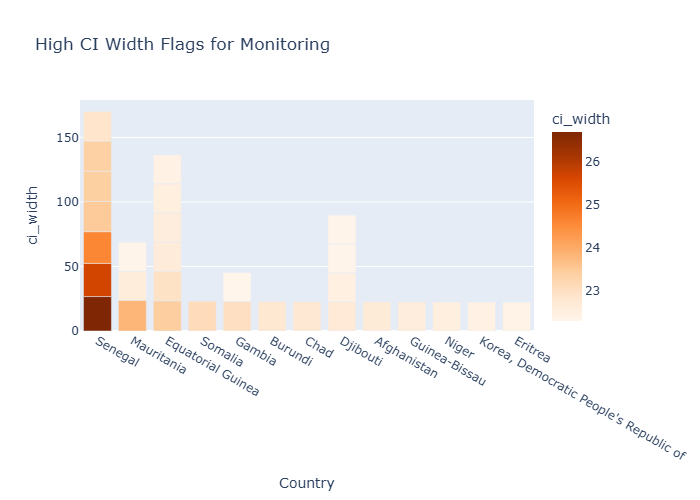

In [41]:
fig = px.bar(
    df,
    x="Country",
    y="ci_width",
    title="High CI Width Flags for Monitoring",
    color="ci_width",
    color_continuous_scale="Oranges"
)
fig.show("png")

# Combined SQL Queries

# C1· Obesity vs malnutrition — 5 countries side by side

In [42]:
# C1· Obesity vs malnutrition — 5 countries side by side

sql = """
SELECT o.Country, o.Year,
       ROUND(o.Mean_Estimate,2) AS obesity_pct,
       ROUND(m.Mean_Estimate,2) AS malnutrition_pct
FROM obesity o JOIN malnutrition m
  ON o.Country=m.Country AND o.Year=m.Year AND o.Gender=m.Gender
WHERE o.Gender='Both'
  AND o.Country IN ('India','Nigeria','United States',
                    'China','Brazil')
ORDER BY o.Country, o.Year;
"""
df = q(sql)
display(df)

,Country,Year,obesity_pct,malnutrition_pct
0,Brazil,2012,19.01,2.53
1,Brazil,2012,19.01,2.69
2,Brazil,2012,19.01,2.77
3,Brazil,2012,19.01,3.39
4,Brazil,2012,7.78,2.53
...,...,...,...,...
875,United States,2022,21.53,1.73
876,United States,2022,18.62,0.96
877,United States,2022,18.62,1.31
878,United States,2022,18.62,1.47


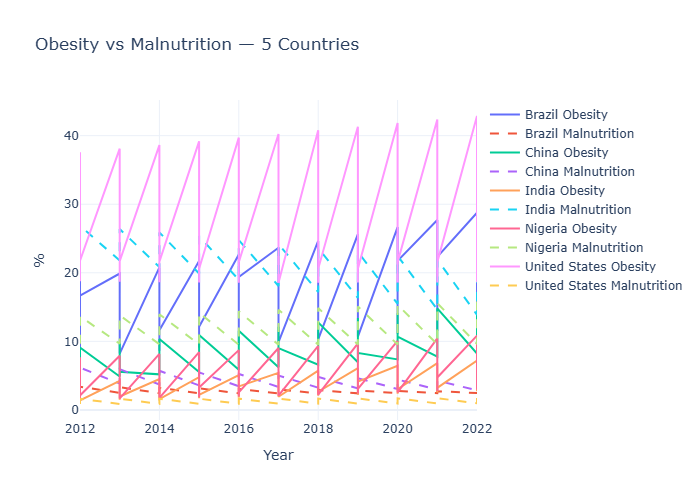

In [43]:
fig = go.Figure()

for country in df["Country"].unique():

    sub = df[df["Country"] == country]

    fig.add_scatter(
        x=sub["Year"],
        y=sub["obesity_pct"],
        name=f"{country} Obesity"
    )

    fig.add_scatter(
        x=sub["Year"],
        y=sub["malnutrition_pct"],
        name=f"{country} Malnutrition",
        line=dict(dash="dash")
    )

fig.update_layout(
    title="Obesity vs Malnutrition — 5 Countries",
    template="plotly_white",
    xaxis_title="Year",
    yaxis_title="%"
)

fig.show("png")

# C2· Gender-based disparity in both conditions

In [44]:
# C2· Gender-based disparity in both conditions

sql = """
SELECT o.Gender,
       ROUND(AVG(o.Mean_Estimate),2) AS avg_obesity,
       ROUND(AVG(m.Mean_Estimate),2) AS avg_malnutrition
FROM obesity o JOIN malnutrition m
  ON o.Country=m.Country AND o.Year=m.Year AND o.Gender=m.Gender
WHERE o.Gender IN ('Male','Female')
GROUP BY o.Gender;
"""
df = q(sql)
display(df)

,Gender,avg_obesity,avg_malnutrition
0,Female,12.72,4.68
1,Male,12.78,6.03


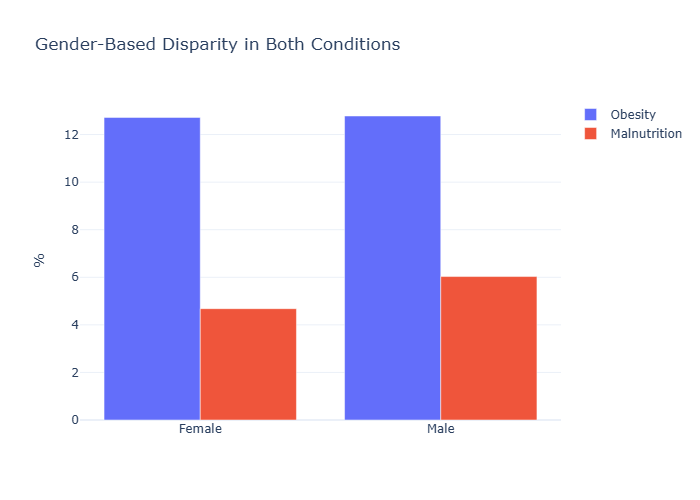

In [45]:
fig = go.Figure(data=[

    go.Bar(
        name="Obesity",
        x=df["Gender"],
        y=df["avg_obesity"]
    ),

    go.Bar(
        name="Malnutrition",
        x=df["Gender"],
        y=df["avg_malnutrition"]
    )

])

fig.update_layout(
    barmode="group",
    title="Gender-Based Disparity in Both Conditions",
    template="plotly_white",
    yaxis_title="%"
)

fig.show("png")


# C3· Region-wise avg estimates — Africa vs Americas

In [46]:
# C3· Region-wise avg estimates — Africa vs Americas

sql = """
SELECT o.Region,
       ROUND(AVG(o.Mean_Estimate),2) AS avg_obesity,
       ROUND(AVG(m.Mean_Estimate),2) AS avg_malnutrition
FROM obesity o JOIN malnutrition m
  ON o.Country=m.Country AND o.Year=m.Year AND o.Gender=m.Gender
WHERE o.Gender='Both'
  AND o.Region IN ('Africa','Americas Region')
GROUP BY o.Region;
"""
df = q(sql)
display(df)

,Region,avg_obesity,avg_malnutrition
0,Africa,5.43,8.51


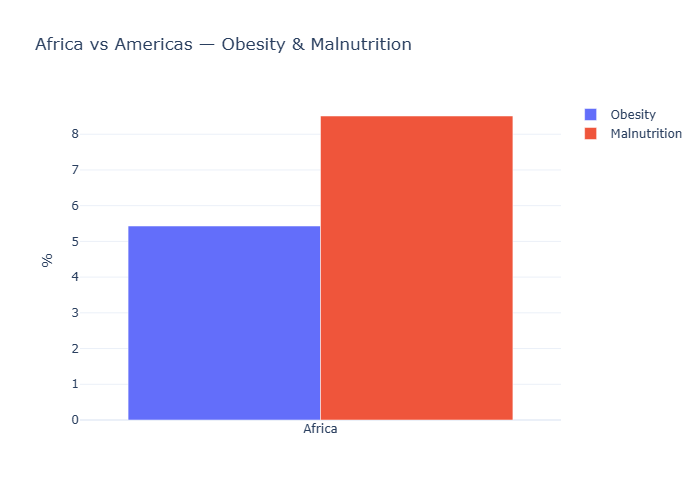

In [47]:
fig = go.Figure(data=[

    go.Bar(
        name="Obesity",
        x=df["Region"],
        y=df["avg_obesity"]
    ),

    go.Bar(
        name="Malnutrition",
        x=df["Region"],
        y=df["avg_malnutrition"]
    )

])

fig.update_layout(
    barmode="group",
    title="Africa vs Americas — Obesity & Malnutrition",
    template="plotly_white",
    yaxis_title="%"
)

fig.show("png")

# C4· Countries where obesity is rising AND malnutrition falling

In [48]:
# C4· Countries where obesity is decreasing AND malnutrition rising

sql = """
SELECT ob.Country,
       ROUND(MIN(ob.Mean_Estimate)-MAX(ob.Mean_Estimate),2) AS ob_drop,
       ROUND(MAX(mn.Mean_Estimate)-MIN(mn.Mean_Estimate),2) AS mn_increase
FROM obesity ob
JOIN malnutrition mn
  ON ob.Country=mn.Country
  AND ob.Year=mn.Year
  AND ob.Gender=mn.Gender
WHERE ob.Gender='Both'
GROUP BY ob.Country
HAVING ob_drop < 0 AND mn_increase > 0
ORDER BY mn_increase DESC
LIMIT 15;
"""

df = q(sql)
display(df)

,Country,ob_drop,mn_increase
0,Eritrea,-3.24,25.10
1,Ethiopia,-2.65,17.13
2,Central African Republic,-5.18,15.19
3,Somalia,-11.20,13.82
4,Madagascar,-3.19,13.42
5,India,-5.82,12.99
6,Pakistan,-19.58,12.96
7,South Sudan,-5.59,12.17
8,"Congo, The Democratic Republic of the",-4.04,11.90
9,Viet Nam,-10.21,11.74


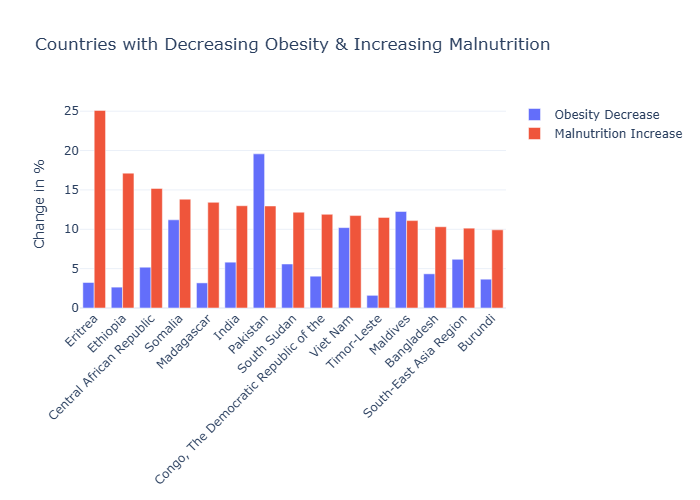

In [49]:
fig = go.Figure(data=[

    go.Bar(
        name="Obesity Decrease",
        x=df["Country"],
        y=abs(df["ob_drop"])
    ),

    go.Bar(
        name="Malnutrition Increase",
        x=df["Country"],
        y=df["mn_increase"]
    )

])

fig.update_layout(
    barmode="group",
    title="Countries with Decreasing Obesity & Increasing Malnutrition",
    template="plotly_white",
    xaxis_tickangle=-45,
    yaxis_title="Change in %"
)

fig.show("png")

# C5· Age-wise trend — adults vs children across both conditions


In [50]:
# C5· Age-wise trend — adults vs children across both conditions

sql = """
SELECT ob.Year, ob.Age_Group,
       ROUND(AVG(ob.Mean_Estimate),2) AS avg_obesity,
       ROUND(AVG(mn.Mean_Estimate),2) AS avg_malnutrition
FROM obesity ob JOIN malnutrition mn
  ON ob.Country=mn.Country AND ob.Year=mn.Year
  AND ob.Gender=mn.Gender AND ob.Age_Group=mn.Age_Group
WHERE ob.Gender='Both'
GROUP BY ob.Year, ob.Age_Group
ORDER BY ob.Year, ob.Age_Group;
"""
df = q(sql)
display(df)

,Year,Age_Group,avg_obesity,avg_malnutrition
0,2012,Adult,19.53,6.44
1,2012,Child/Adolescent,8.26,5.28
2,2013,Adult,19.96,6.32
3,2013,Child/Adolescent,8.52,5.25
4,2014,Adult,20.41,6.21
5,2014,Child/Adolescent,8.79,5.22
6,2015,Adult,20.86,6.10
7,2015,Child/Adolescent,9.07,5.19
8,2016,Adult,21.33,6.00
9,2016,Child/Adolescent,9.36,5.17


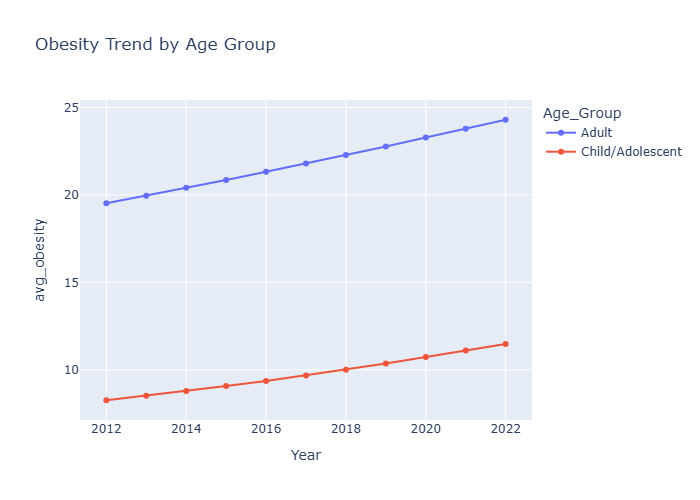

In [51]:
fig = px.line(
    df,
    x="Year",
    y="avg_obesity",
    color="Age_Group",
    title="Obesity Trend by Age Group",
    markers=True
)

fig.show("png")

fig2 = px.line(
    df,
    x="Year",
    y="avg_malnutrition",
    color="Age_Group",
    title="Malnutrition Trend by Age Group",
    markers=True
)
